In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [23]:
print(torch.__version__)

2.13.0+cu130


In [24]:
torch.manual_seed(42)
np.random.seed(42)

In [25]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])
    b = torch.tensor(-0.7)
    x = torch.tensor([x1, x2], dtype=torch.float32)
    output = torch.dot(w, x) + b
    return 1 if output >= 0 else 0

print(perceptron_and(0, 0))
print(perceptron_and(0, 1))
print(perceptron_and(1, 0))
print(perceptron_and(1, 1))


0
0
0
1


In [26]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [27]:
class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [28]:
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
dataset = TensorDataset(X_train, y_train)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [29]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    print(epoch + 1, loss.item())

1 0.9306033849716187
2 1.979332447052002
3 0.5246674418449402
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [30]:
torch.save(model.state_dict(), 'model.pth')
model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
model.load_state_dict(torch.load('model.pth'))

<All keys matched successfully>

In [31]:
def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss is NaN. Stopping training.")
        
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.1

        return True
    return False

sample_loss = torch.tensor(float('nan'))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)

Loss is NaN. Stopping training.
True


In [32]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])


In [33]:
# MNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', 
                                            train=True, 
                                            download=True, 
                                            transform=transform)

test_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=False,
                                           download=True, 
                                           transform=transform)

In [34]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

print(len(train_loader))
print(len(test_loader))

938
10


In [35]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [36]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [38]:
for epoch in range(10):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    print(epoch + 1, loss.item())

1 0.33766061067581177
2 0.06099878251552582
3 0.0797526091337204
4 0.03630278632044792
5 0.006269311066716909
6 0.001200592378154397
7 0.010193279944360256
8 0.05158279836177826
9 0.0024243751540780067
10 0.012348104268312454


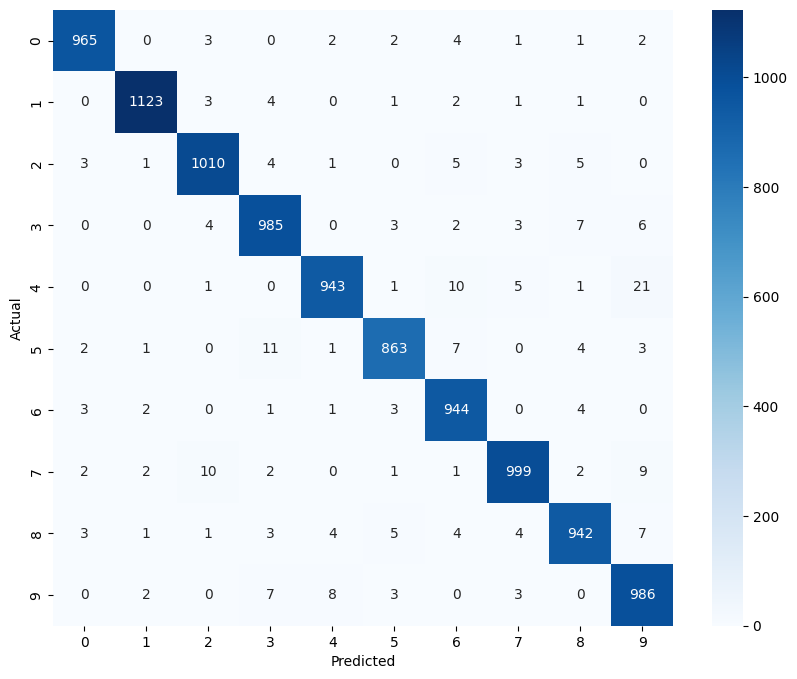

In [39]:
model.eval()
all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, preds = torch.max(output, 1)
        all_targets.extend(target.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

targets = np.array(all_targets)
preds = np.array(all_preds)

cm_mnist = confusion_matrix(targets, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mnist, 
annot=True, 
fmt='d', 
cmap='Blues',
xticklabels=range(10),
yticklabels=range(10))

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

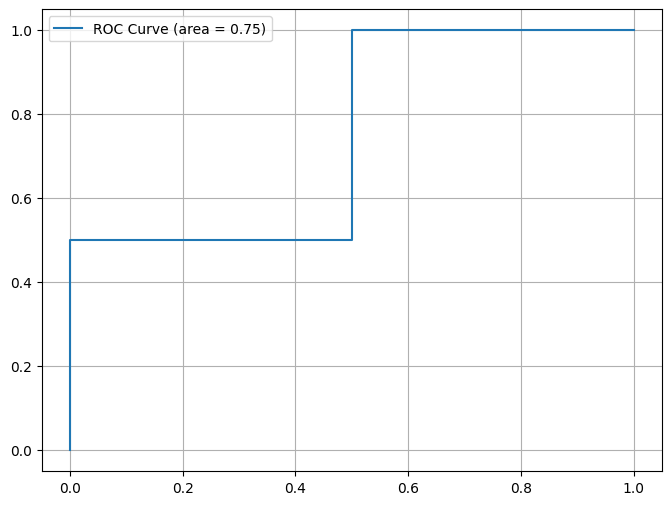

In [40]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label = f'ROC Curve (area = {roc_auc:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from torch.optim.lr_scheduler import ReduceLROnPlateau  

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
for epoch in range(50):
    
    # train_one_epoch(model, train_loader, ...)
    # val_loss = evaluate(model, val_loader)
    # scheduler.step(val_loss)
   
    train_loss = 0.2 * (50 - epoch)
    scheduler.step(train_loss)

In [ ]:
# 배치정규화

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)

        return x

In [43]:
# dropout

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout1 = nn.Dropout(0.5)
        # self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        # self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.dropout1(self.fc1(x)))
        x = F.relu(self.dropout2(self.fc2(x)))
        x = self.fc3(x)

        return x